In [1]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'

from AI4AO import PyramidWFS, DeformableMirror

from mmengine import Config
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

In [2]:
ekarus_iMat = np.load("../Data/Ekarus/IM.npy").T
ekarus_iMat = torch.from_numpy(ekarus_iMat.astype(np.float32)).to(device = device, dtype=torch.float32)

nModes = ekarus_iMat.shape[0]

M2C = np.load("../Data/Ekarus/M2C_KL_OOPAO.npy")
M2C = torch.from_numpy(M2C).to(device = device, dtype = torch.float32)
M2C = M2C[:, :nModes]

valid_pix = np.load("../Data/Ekarus/valid_pix_map.npy").astype(np.bool_)
W,H = valid_pix.shape
nPix = int(valid_pix.sum())

ekarus_iMat = ekarus_iMat[:,:nPix]

iMat = torch.zeros((nModes,W,H)).to(device = device, dtype=torch.float32)
iMat[:, valid_pix] = ekarus_iMat
iMat = iMat[:, 40:-60, 50:-50]

reference_frame = torch.from_numpy(valid_pix).to(device = device, dtype=torch.float32)
reference_frame /= reference_frame.sum()
reference_frame = reference_frame[40:-60, 50:-50]

In [9]:
paramfile = 'Ekarus_params.py'  # file of experimental parameters

# Config extraction

WFSParams = Config.fromfile(paramfile)['WFSParams']
DMParams = Config.fromfile(paramfile)['DMParams']

In [10]:
wfs = PyramidWFS(WFSParams, device)

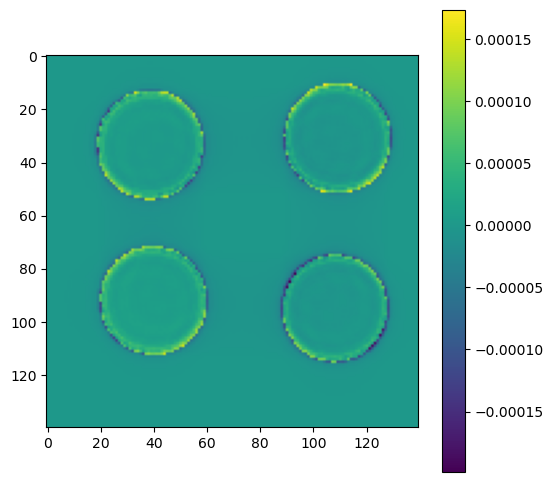

In [12]:
final_train_loss = 0

TrainRunNb = 200
loss = torch.nn.MSELoss()

fig,ax = plt.subplots(figsize = (6,6))


img = ax.imshow(reference_frame.cpu().detach().numpy())
fig.colorbar(img)
plt.show()

optimizer = torch.optim.AdamW(wfs.parameters(), 1e-3, fused = True)

wfs.train()

for u in range(0,TrainRunNb) :

    optimizer.zero_grad()
    
    wfs.BuildMask()

    wfs.BuildReferenceIntensity() 

    digital_image = wfs.reference_intensity
    
    l = (torch.abs(reference_frame-digital_image)**2).sum()

    l. backward()
    
    optimizer.step()
    
    if u % 10 == 0:
        clear_output(wait=True)
        img.set_data((reference_frame - wfs.reference_intensity).cpu().detach().numpy())
        img.set_clim(vmin=np.min(img.get_array()), vmax=np.max(img.get_array()))
        display(fig, clear=True)
        plt.pause(0.1)
    



In [13]:
param = {}
param['rotationAngle'] = 0
# shift X in m
param['shiftX'] = 0
# shift Y in m
param['shiftY'] = 0
# amamorphosis angle in degrees
param['anamorphosisAngle'] = 0
# normal scaling in % of diameter
param['tangentialScaling'] = 0
# radial scaling in % of diameter
param['radialScaling'] = 0

dm = DeformableMirror(WFSParams,
                    DMParams,
                    device=device,
                    misreg=param)


wfs.BuildReferenceIntensity()
dm.RoughCalibration(wfs, iMat, M2C)


Best configuration found to be: 
Rotation angle: 90.0
Sign: Possitive
Flip left-right: True
Flip top-bottom: False

Updating values in the DM


In [14]:
ref_phase = torch.nn.Parameter(torch.zeros(*wfs.pupil.shape, device = device, dtype = torch.float32))
ref_pupil = torch.nn.Parameter(torch.ones(*wfs.pupil.shape, device = device, dtype = torch.float32))

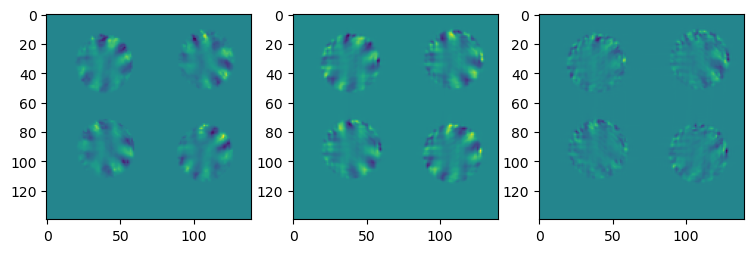

In [17]:
index = list(range(0,400,5))
target = iMat[index]

modes = dm(M2C[:,index].T)

wfs.BuildInteractionMatrix(modes, pupil = ref_pupil, batch_size=30, phaseOffset=ref_phase)
digital_image = wfs.iMat

idx = 5
plt.figure(figsize=(9,4))
plt.subplot(131)
plt.imshow(target[idx].cpu().numpy())

plt.subplot(132)
plt.imshow(digital_image[idx].cpu().detach().numpy())

plt.subplot(133)
plt.imshow((target - digital_image)[idx].cpu().detach().numpy(), vmin=(target)[idx].cpu().detach().numpy().min(), vmax=(target)[idx].cpu().detach().numpy().max())

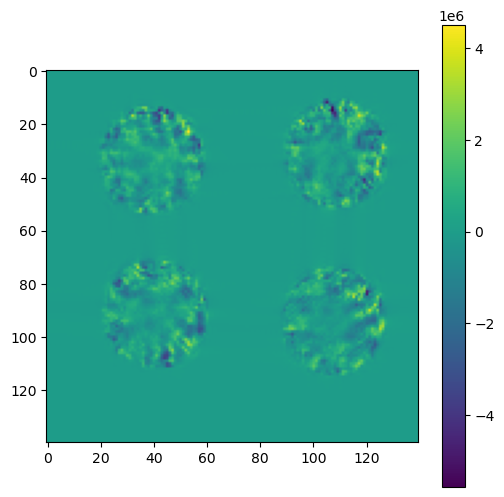

########################################
loss = 0.07958
########################################
({'rotationAngle': 88.68212127685547, 'shiftX': -0.00032848379225470126, 'shiftY': 0.0020767055619508026, 'anamorphosisAngle': 4.887717247009277, 'tangentialScaling': -1.6481449827551842, 'radialScaling': 0.007428537355735898}, {'moffatParam': 1.6730929613113403, 'signedAmplitude': 3.87398358725477e-06, 'MechCoupling': 0.5543343424797058, 'FlipLeftRight': True, 'FlipTopBottom': False, 'offset_to_fit_number_of_actuators': 0.2})


In [81]:
wfs.train()
dm.train()

TrainRunNb = 200

loss = torch.nn.MSELoss()

fig,ax = plt.subplots(figsize = (6,6))

img = ax.imshow(target[4].cpu().detach().numpy())
fig.colorbar(img)

original_positons = dm.anamorphosis_coordinates(dm.actuator_positions)
original_positons = dm.rotate_coordinates(original_positons)


warmup_iters = TrainRunNb // 2
lr_start = -10
lr_end = -2

optimizer = torch.optim.AdamW(  [{"params": dm.parameters(), "lr": 1e-2},
                                {"params": [ref_phase, ref_pupil], "lr": 10**lr_start},
                                {"params": wfs.parameters(), "lr": 1e-3}],
                                fused=True
                                )


wfs.reference_intensity = None

for u in range(0,TrainRunNb) :

    if u < warmup_iters:
        alpha = u / warmup_iters
        optimizer.param_groups[1]["lr"] = 10**(
            lr_start + alpha * (lr_end - lr_start)
        )
    if u == warmup_iters:
        optimizer.param_groups[1]["lr"] = 10**lr_end
    
    optimizer.zero_grad()

    wfs.BuildMask()
    modes = dm(M2C[:,index].T)

    wfs.BuildInteractionMatrix(modes, pupil = ref_pupil, batch_size=30, phaseOffset=ref_phase)

    digital_image = wfs.iMat
    
    l = ((target - digital_image)**2).sum()

    l. backward()
    
    optimizer.step()
    
    if u % 10 == 0:
        clear_output(wait=True)
        img.set_data((target - digital_image)[4].cpu().detach().numpy()*1e10)
        img.set_clim(vmin=np.min(img.get_array()), vmax=np.max(img.get_array()))
        display(fig, clear=True)
        plt.pause(0.5)

        print("#"*40)
        print(f'loss = {l.item():.5f}')
        print("#"*40)
    
print(dm.GetMisreg())

transformed_positons = dm.anamorphosis_coordinates(dm.actuator_positions)
transformed_positons = dm.rotate_coordinates(transformed_positons)

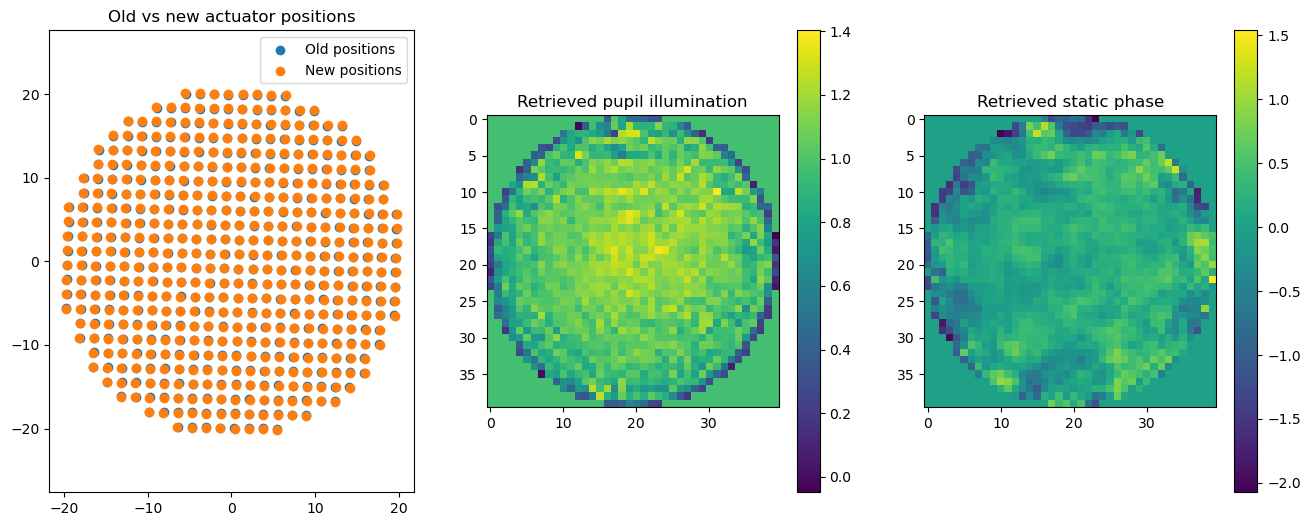

In [82]:
plt.figure(figsize=(16,6))
plt.subplot(131)
plt.title("Old vs new actuator positions")
plt.scatter(original_positons[:,0].cpu().detach(), original_positons[:,1].cpu().detach())
plt.scatter(transformed_positons[:,0].cpu().detach(), transformed_positons[:,1].cpu().detach())
plt.legend(['Old positions', 'New positions'])
plt.axis('equal')
plt.subplot(132)
plt.title('Retrieved pupil illumination')
plt.imshow(ref_pupil.cpu().detach())
plt.colorbar()
plt.subplot(133)
plt.title('Retrieved static phase')
plt.imshow(ref_phase.cpu().detach())
plt.colorbar()

In [83]:
dm.eval()
modes = dm(M2C.T)

with torch.no_grad():
    wfs.BuildReconstructionMatrix(modes, pupil = ref_pupil, batch_size=30, phaseOffset=ref_phase)

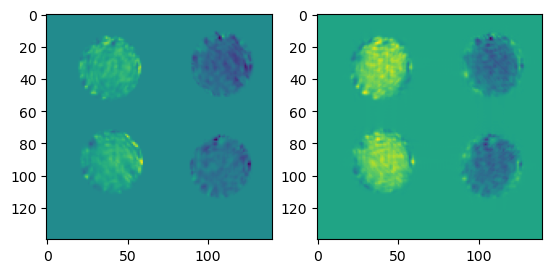

In [84]:
idx = 0
plt.subplot(121)
plt.imshow((iMat)[idx].cpu().detach().numpy())
plt.subplot(122)
plt.imshow((wfs.iMat)[idx].cpu().detach().numpy())

In [85]:
with torch.no_grad():
    cov = iMat.flatten(start_dim = -2) @ wfs.reconstructionMatrix

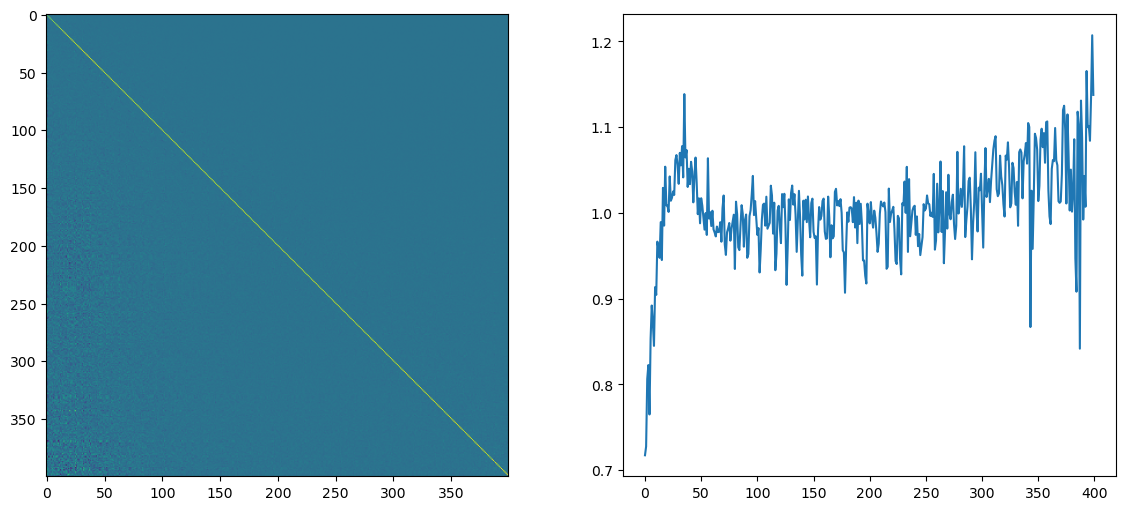

In [87]:
plt.figure(figsize=(14,6))
plt.subplot(121)
plt.imshow(cov.cpu().detach())
plt.subplot(122)
plt.plot(torch.diag(cov).cpu().detach())

In [88]:
PATH_WFS = "../Data/Ekarus/EkarusWFS.pth"
wfs.SaveCalibration(PATH_WFS)

PATH_DM = "../Data/Ekarus/EkarusDM.pth"
dm.SaveCalibration(PATH_DM)

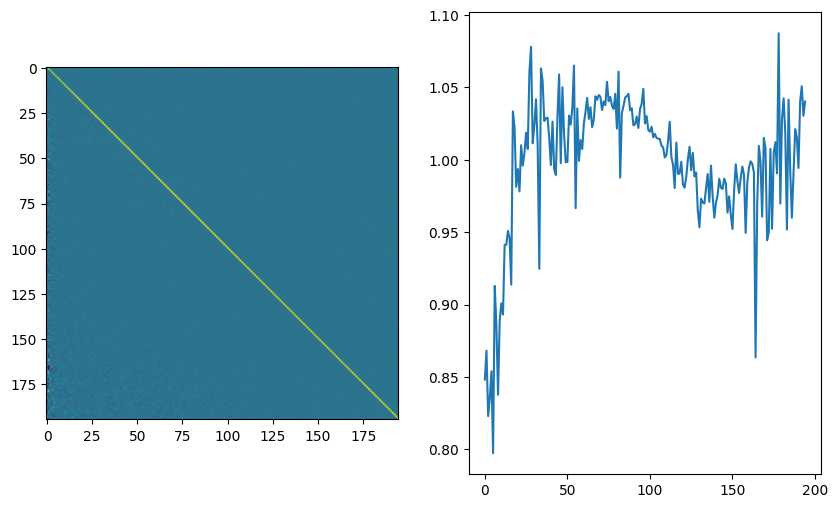

In [ ]:
wfs = PyramidWFS(WFSParams, device)
wfs.LoadCalibration(PATH_WFS)
wfs.eval()

dm = DeformableMirror(WFSParams,
                    DMParams,
                    device=device)
dm.LoadCalibration(PATH_DM)
dm.eval()

modes = dm(M2C.T)

with torch.no_grad():
    wfs.BuildReconstructionMatrix(modes, pupil = ref_pupil, batch_size=30, phaseOffset=ref_phase)

with torch.no_grad():
    cov = iMat.view(195,-1) @ wfs.reconstructionMatrix

plt.figure(figsize=(10,6))
plt.subplot(121)
plt.imshow(cov.cpu().detach())
plt.subplot(122)
plt.plot(torch.diag(cov).cpu().detach())